In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.nn.functional import conv2d, conv3d
from scipy.ndimage import convolve, generate_binary_structure
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

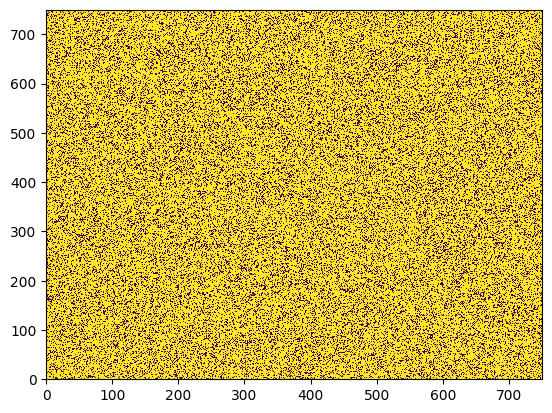

In [3]:
N = 750

init_random = torch.rand((N,N)).to(device)
lattice_n = torch.zeros((N, N)).to(device)
lattice_n[init_random>=0.75] = 1
lattice_n[init_random<0.75] = -1

init_random = torch.rand((N,N)).to(device)
lattice_p = torch.zeros((N, N)).to(device)
lattice_p[init_random>=0.25] = 1
lattice_p[init_random<0.25] = -1
plt.pcolormesh(lattice_p.cpu())

In [4]:
def get_energy_arr(lattices, B=0):
    # applies the nearest neighbours summation
    kern = generate_binary_structure(2, 1) 
    kern[1][1] = False
    kern = torch.tensor(kern.astype(np.float32)).unsqueeze(dim=0).unsqueeze(dim=0).to(device)
    arr = -lattices * conv2d(lattices, kern, padding='same') + B * lattices
    return arr
    
def get_energy(lattices, B=0):
    # applies the nearest neighbours summation
    return get_energy_arr(lattices, B).sum(axis=(1,2,3))

def get_dE_arr(lattices, B=0):
    return -2*get_energy_arr(lattices, B)

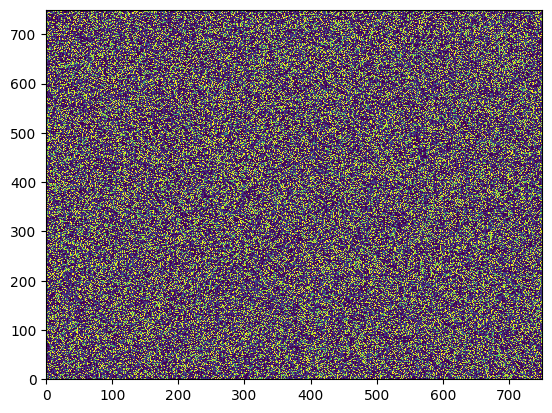

In [5]:
lattices = torch.stack([lattice_n, lattice_p]).unsqueeze(dim=1)
get_energy(lattices, 3).shape
plt.pcolormesh(get_energy_arr(lattices, 6).cpu()[0,0])
plt.show()

In [6]:
def metropolis(spin_tensor_batch, times, BJs, B=0):
    energies = []
    avg_spins = []
    spin_tensor_batch = torch.clone(spin_tensor_batch)
    BJs = BJs.reshape([-1,1,1,1])
    for t in range(times):
        i = np.random.randint(0,2)
        j = np.random.randint(0,2)
        dE = get_dE_arr(spin_tensor_batch, B)[:,:,i::2,j::2]
        change = (dE>=0)*(torch.rand(dE.shape).to(device) < torch.exp(-BJs*dE)) + (dE<0)
        spin_tensor_batch[:,:,i::2,j::2][change] *=-1
        energies.append(get_energy(spin_tensor_batch, B))
        avg_spins.append(spin_tensor_batch.sum(axis=(1,2,3))/N**2)
    return torch.vstack(avg_spins), torch.vstack(energies)

In [8]:
BJs = 0.5*torch.ones(lattices.shape[0]).to(device)
spins, energies = metropolis(lattices, 1000, BJs, B=0.00)

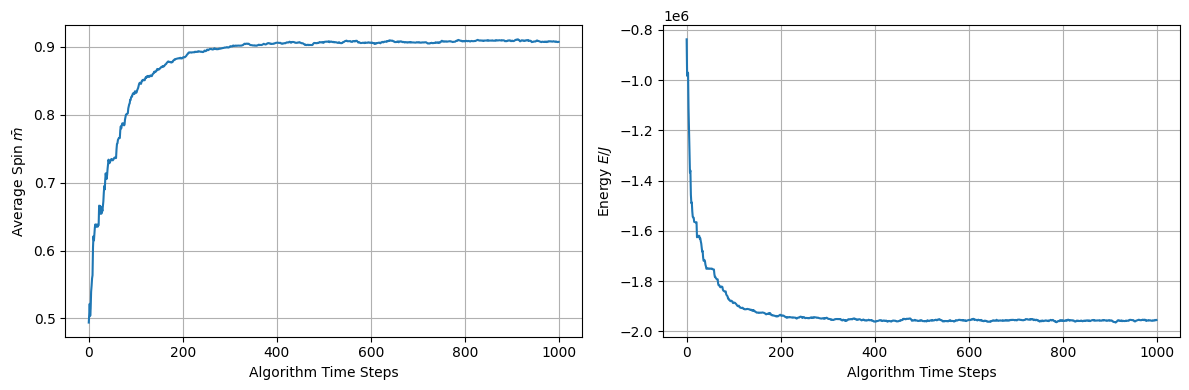

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
ax = axes[0]
ax.plot(spins[:,1].cpu())
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Average Spin $\bar{m}$')
ax.grid()
ax = axes[1]
ax.plot(energies[:,1].cpu())
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Energy $E/J$')
ax.grid()
fig.tight_layout()
plt.show()

In [10]:
def get_spin_energy(lattice, BJs, B=0):
    lattices = lattice.unsqueeze(dim=0).repeat(len(BJs),1,1,1)
    spins, energies = metropolis(lattices, 1000, BJs, B)
    spins_avg = torch.mean(spins[-400:], axis=0)
    energies_avg = torch.mean(energies[-400:], axis=0)
    energies_std = torch.std(energies[-400:], axis=0)
    return spins_avg, energies_avg, energies_std

BJs = 1/torch.linspace(0.5, 6, 60).to(device)
spins_avg_n, E_means_n, E_stds_n = get_spin_energy(lattice_n, BJs, B=0.0)
spins_avg_p, E_means_p, E_stds_p = get_spin_energy(lattice_p, BJs, B=0.0)

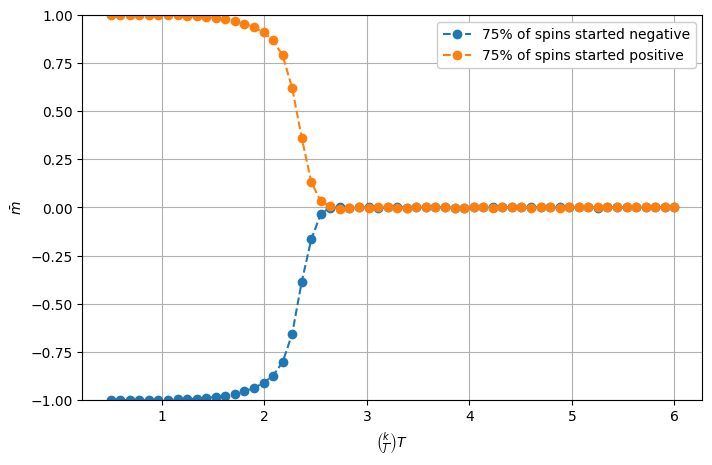

In [11]:
plt.figure(figsize=(8,5))
plt.plot(1/BJs.cpu(), spins_avg_n.cpu(), 'o--', label='75% of spins started negative')
plt.plot(1/BJs.cpu(), spins_avg_p.cpu(), 'o--', label='75% of spins started positive')
plt.xlabel(r'$\left(\frac{k}{J}\right)T$')
plt.ylabel(r'$\bar{m}$')
plt.ylim(-1, 1)
plt.grid()
plt.legend(facecolor='white', framealpha=1)
plt.show()

In [170]:
BJs = 1/torch.linspace(0.5, 6, 60).to(device)
B = torch.linspace(0, 0.5, 60).to(device)
spins_n = []
spins_p = []
for b in B:
    print(f'{100*b/0.5:.2f}% done', end='\r')
    spins_avg_n, E_means_n, E_stds_n = get_spin_energy(lattice_n, BJs, B=b)
    spins_avg_p, E_means_p, E_stds_p = get_spin_energy(lattice_p, BJs, B=b)
    spins_n.append(spins_avg_n)
    spins_p.append(spins_avg_p)

spins_n = torch.vstack(spins_n)
spins_p = torch.vstack(spins_p)

(torch.Size([60, 60]), torch.Size([60, 60]))

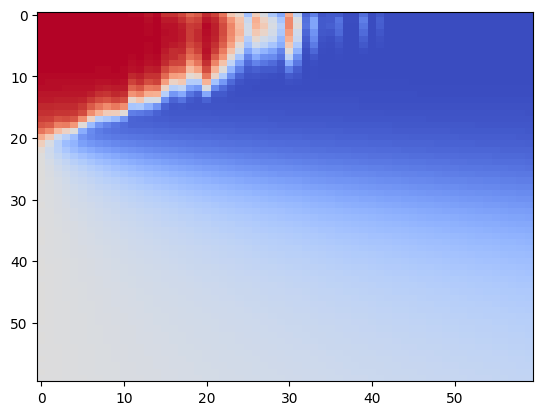

In [172]:
plt.imshow(spins_p.cpu().T, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
spins_n.shape, spins_p.shape

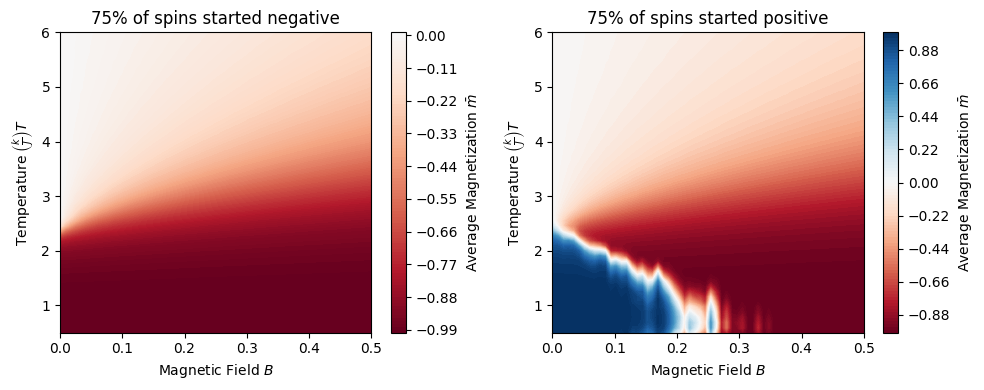

In [173]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].set_title('75% of spins started negative')
axes[1].set_title('75% of spins started positive')
cont0 = axes[0].contourf(B.cpu(), 1/BJs.cpu(), spins_n.cpu().T, levels=100, cmap='RdBu', vmin=-1, vmax=1)
cont1 = axes[1].contourf(B.cpu(), 1/BJs.cpu(), spins_p.cpu().T, levels=100, cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_ylabel(r'Temperature $\left(\frac{k}{J}\right)T$')
axes[0].set_xlabel(r'Magnetic Field $B$')
axes[1].set_xlabel(r'Magnetic Field $B$')
axes[1].set_ylabel(r'Temperature $\left(\frac{k}{J}\right)T$')
plt.colorbar(cont0, ax=axes[0], label=r'Average Magnetization $\bar{m}$')
plt.colorbar(cont1, ax=axes[1], label=r'Average Magnetization $\bar{m}$')
fig.tight_layout()
plt.show()
fig.savefig('/Users/hasan/Python Animations/ising_model.png', dpi=300, bbox_inches='tight')